# Logistic regression 

In [1]:
from vplearn.classification import LogisticRegression
from vplearn.metrics import Accuracy, Precision, Recall
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from pathlib import Path

base_dir = Path.cwd()
print(base_dir)

np.random.seed(2)

f:\Learning\ML\examples\03_KNN_and_Logistic_Regression


## Ví dụ B.1

In [2]:
X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50,2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
# X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)
X = X.T
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])
y = y.reshape(-1, 1)

lr = LogisticRegression(activate='sigmoid')
lr.fit(X, y)
y_pred = lr.predict(X)
print("Predicted probabilities:\n", y_pred)
print("Labels: \n", y.reshape(-1))

accuracy = Accuracy(y, y_pred)
precision = Precision(y, y_pred)
recall = Recall(y, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

X_test = np.array([[2.45], [1.85], [3.75], [3.21], [4.05]])
y_test_pred = lr.predict(X_test)

print("\nTest set predicted:\n", y_test_pred)

Predicted probabilities:
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]
Labels: 
 [0 0 0 0 0 0 1 0 1 0 1 0 1 0 1 1 1 1 1 1]
Accuracy: 0.5000
Precision: 0.5000
Recall: 0.5000

Test set predicted:
 [0 0 1 1 1]


## Ví dụ B.2

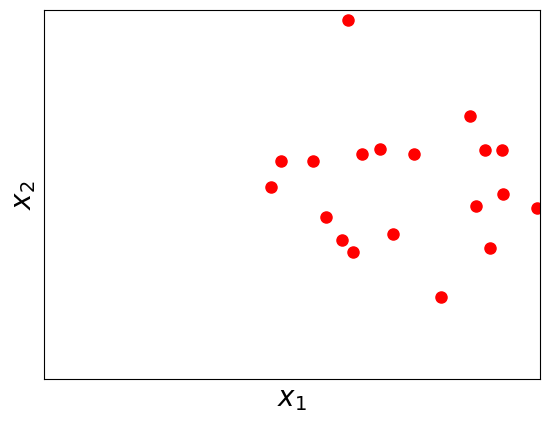

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
# generate list of data points
np.random.seed(22)
means = [[2, 2], [4, 2]]
cov = [[.7, 0], [0, .7]]
N = 20

X1 = np.random.multivariate_normal(means[0], cov, N)
X2 = np.random.multivariate_normal(means[1], cov, N)

plt.plot(X2[:, 0], X2[:, 1], 'ro', markersize = 8, alpha = 1)
plt.axis('equal')
plt.ylim(0, 4)
plt.xlim(0, 5)
# hide tikcs
cur_axes = plt.gca()
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])
plt.xlabel('$x_1$', fontsize = 20)
plt.ylabel('$x_2$', fontsize = 20)
plt.show()

In [4]:
def sigmoid(s):
    return 1/(1 + np.exp(-s)) # calculate sigmoid function

def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]
    it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    while count < max_count:
        # mix data for stochastic gradient descent method
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            # stopping criteria
            if count%check_w_after == 0:
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w

In [5]:
X = np.concatenate((X1, X2), axis = 0).T
y = np.concatenate((np.zeros((1, N)), np.ones((1, N))), axis = 1).T
# Xbar
X = np.concatenate((np.ones((1, 2*N)), X), axis = 0)
eta = 0.05
d = X.shape[0]
w_init = np.random.randn(d, 1) # initialize parameters w = w_init
# call logistic_sigmoid_regression procedure
w = logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count= 10000)
# print out the parameter
print(w[-1])

[[-9.51043127]
 [ 2.25978315]
 [ 1.42588178]]


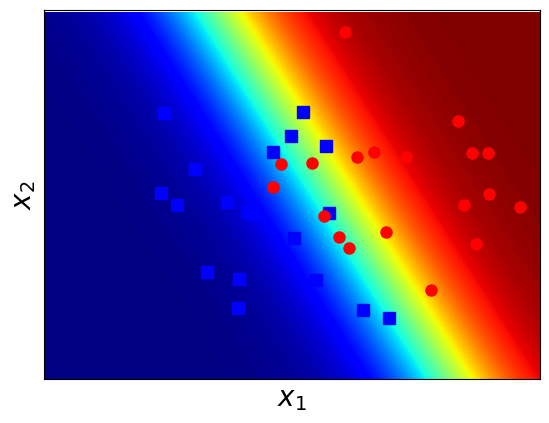

In [6]:
# Make data.
x1m = np.arange(-1, 6, 0.025) # generate data coord. X1
xlen = len(x1m)
x2m = np.arange(0, 4, 0.025) # generate data coord. X2
x2en = len(x2m)
x1m, x2m = np.meshgrid(x1m, x2m) # create mesh grid X = (X1, X2)
# now assign the parameter w0, w1, w2 from array w which was computed above
w0 = w[-1][0][0]
w1 = w[-1][1][0]
w2 = w[-1][2][0]
# calculate probability zm=P(c|x)=sigmoid(w^Tx)=sigmoid(w0+w1*x1m+w2*x2m)
zm = sigmoid(w0 + w1*x1m + w2*x2m)
# plot contour of prob. zm by the saturation of blue and red
# more red <=> prob. that data point belong to red class is higher & vise versa
CS = plt.contourf(x1m, x2m, zm, 200, cmap='jet')
# finally, plot the data and take a look
plt.plot(X1[:, 0], X1[:, 1], 'bs', markersize = 8, alpha = 1)
plt.plot(X2[:, 0], X2[:, 1], 'ro', markersize = 8, alpha = 1)
plt.axis('equal')
plt.ylim(0, 4)
plt.xlim(0, 5)
# hide tikcs
cur_axes = plt.gca()
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])
plt.xlabel('$x_1$', fontsize = 20)
plt.ylabel('$x_2$', fontsize = 20)
plt.show()

## Ví dụ B.3

In [7]:
import time

### a.

In [8]:
df = pd.read_csv(f"{base_dir}\\data\\Admission_Predict.csv")
df.head()

X = df.drop(columns=['Serial No.', 'Chance of Admit']).values
y = df['Chance of Admit'].values.reshape(-1, 1)
y = (y >= 0.75).astype(int) # convert to binary labels

X_train = X[:350]
y_train = y[:350]
X_test = X[350:]
y_test = y[350:]

start = time.time()
lr = LogisticRegression(activate='sigmoid')
lr.fit(X_train, y_train)
y_test_pred = lr.predict(X_test)
end = time.time()
print(f"Time taken for training and prediction: {end - start:.4f} seconds")


accuracy = Accuracy(y_test, y_test_pred)
precision = Precision(y_test, y_test_pred)
recall = Recall(y_test, y_test_pred)
print(f"Test Accuracy: {accuracy:.4f}") 
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

Time taken for training and prediction: 0.0939 seconds
Test Accuracy: 0.5288
Test Precision: 0.5000
Test Recall: 0.5000


F:\Learning\ML\vplearn\classification\logistic_regression.py:77: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-s))


### b.

In [9]:
from vplearn.regression import LinearRegression
from vplearn.metrics import MSE


df = pd.read_csv(f"{base_dir}\\data\\Admission_Predict.csv")
df.head()

X = df.drop(columns=['Serial No.', 'Chance of Admit']).values
y = df['Chance of Admit'].values.reshape(-1, 1)

X_train = X[:350]
y_train = y[:350]
X_test = X[350:]
y_test = y[350:]

lm = LinearRegression()
lm.fit(X_train, y_train)
y_test_pred = lm.predict(X_test)

mse = MSE(y_test, y_test_pred)
print(f"Test MSE: {mse:.4f}")

Test MSE: 0.0440


### c.

In [10]:
from vplearn.classification.naive_bayes import GaussianNB
import time

f = pd.read_csv(f"{base_dir}\\data\\Admission_Predict.csv")
df.head()

X = df.drop(columns=['Serial No.', 'Chance of Admit', 'Research']).values
y = df['Chance of Admit'].values.reshape(-1, 1)
y = (y >= 0.75).astype(int) # convert to binary labels

X_train = X[:350]
y_train = y[:350]
X_test = X[350:]
y_test = y[350:]

start = time.time()
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_test_pred = gnb.predict(X_test)
end = time.time()
print(f"Time taken for training and prediction: {end - start:.4f} seconds")

accuracy = Accuracy(y_test, y_test_pred)
precision = Precision(y_test, y_test_pred)
recall = Recall(y_test, y_test_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

Time taken for training and prediction: 0.0256 seconds
Test Accuracy: 0.5168
Test Precision: 0.5000
Test Recall: 0.5000


## Ví dụ B.4

In [1]:
from vplearn.classification import LogisticRegression
from vplearn.metrics import Accuracy, Precision, Recall
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from pathlib import Path

base_dir = Path.cwd()
print(base_dir)

np.random.seed(2)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

df = pd.read_csv(f"{base_dir}\\data\\banking.csv")

# convert field of 'month'
dict_month = {'jan' : 1, 'feb' : 2, 'mar' : 3, 'apr' : 4, 'may' : 5, 'jun' : 6,
'jul' : 7, 'aug' : 8, 'sep' : 9, 'oct' : 10, 'nov' : 11, 'dec' : 12}
df['month'] = df['month'].map(dict_month)
# convert field of dayOfweek
dict_day = {'sun' : 1, 'mon' : 2, 'tue' : 3, 'wed' : 4, 'thu' : 5, 'fri' : 6,
'sat' : 7}
df['day_of_week'] = df['day_of_week'].map(dict_day)

# conver binary fields
#default :
df.default.replace({'no' : 0, 'yes' : 1}, inplace = True)
#housing :
df.housing.replace({'no' : 0, 'yes' : 1}, inplace = True)
#loan :
df.loan.replace({'no' : 0, 'yes' : 1}, inplace = True)

# one hot encoding
from vplearn.preprocessing.encoding import Encoding
encoder = Encoding()

df = encoder.one_hot_encoding(df, ['job', 'education', 'marital', 'contact', 'poutcome'], y = 'y')

# filter out all unknown values
df = df[df != 'unknown'].dropna()

df.head()

f:\Learning\ML\examples\03_KNN_and_Logistic_Regression


,age,default,housing,loan,month,day_of_week,duration,campaign,pdays,previous,...,education_professional.course,education_university.degree,education_unknown,marital_married,marital_single,marital_unknown,contact_telephone,poutcome_nonexistent,poutcome_success,y
1,53,0,0,0,11,6,138,1,999,0,...,0,0,1,1,0,0,0,1,0,0
2,28,0,1,0,6,5,339,3,6,2,...,0,1,0,0,1,0,0,0,1,1
3,39,0,0,0,4,6,185,2,999,0,...,0,0,0,1,0,0,0,1,0,0
4,55,0,1,0,8,6,137,1,3,1,...,0,0,0,1,0,0,0,0,1,1
5,30,0,1,0,7,3,68,8,999,0,...,0,0,0,0,0,0,0,1,0,0


In [8]:
from vplearn.preprocessing import train_test_split
from vplearn.classification import LogisticRegression 
import time

X = df.drop(columns=['y']).values
y = df['y'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

start = time.time()
lr = LogisticRegression(activate='sigmoid')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
end = time.time()
print(f"Time taken for training and prediction: {end - start:.4f} seconds")

accuracy = Accuracy(y_test, y_pred)
precision = Precision(y_test, y_pred)
recall = Recall(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

F:\Learning\ML\vplearn\classification\logistic_regression.py:78: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-s))


Time taken for training and prediction: 0.0674 seconds
Test Accuracy: 0.8684
Test Precision: 0.5000
Test Recall: 0.5000


In [3]:
df.columns

Index(['age', 'default', 'housing', 'loan', 'month', 'day_of_week', 'duration',
       'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'marital_married', 'marital_single',
       'marital_unknown', 'contact_telephone', 'poutcome_nonexistent',
       'poutcome_success', 'y'],
      dtype='object')

In [7]:
from vplearn.classification.naive_bayes import BernouliNB
from vplearn.metrics import Accuracy, Precision, Recall
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import time
from pathlib import Path

base_dir = Path.cwd()
print(base_dir)

np.random.seed(2)


X = df.drop(
    columns=
    [
        'y', 
        'age', 
        'month', 
        'day_of_week', 
        'duration', 
        'campaign', 
        'pdays', 
        'previous',
        'emp_var_rate',
        'cons_price_idx',
        'cons_conf_idx',
        'euribor3m',
        'nr_employed'
    ]
).values
y = df['y'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

start = time.time()
gnb = BernouliNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
end = time.time()
print(f"Time taken for training and prediction: {end - start:.4f} seconds")

accuracy = Accuracy(y_test, y_pred)
precision = Precision(y_test, y_pred)
recall = Recall(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

f:\Learning\ML\examples\03_KNN_and_Logistic_Regression
<class 'pandas.core.series.Series'>
Time taken for training and prediction: 0.1487 seconds
Test Accuracy: 0.8781
Test Precision: 0.7362
Test Recall: 0.5947


## Ví dụ B.6

In [13]:
from vplearn.classification import LogisticRegression
from vplearn.preprocessing import train_test_split
from vplearn.metrics import Accuracy, Precision, Recall
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from pathlib import Path

base_dir = Path.cwd()
print(base_dir)

np.random.seed(2)

df = pd.read_csv(f"{base_dir}\\data\\framingham.csv")
df.head()
df=df.dropna(how="any", axis=0)
df.describe()

X = df.drop(columns=['TenYearCHD']).values
y = df['TenYearCHD'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

start = time.time()
lr = LogisticRegression(activate='sigmoid')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
end = time.time()
print(f"Time taken for training and prediction: {end - start:.4f} seconds")

accuracy = Accuracy(y_test, y_pred)
precision = Precision(y_test, y_pred)
recall = Recall(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

f:\Learning\ML\examples\03_KNN_and_Logistic_Regression
Time taken for training and prediction: 0.0120 seconds
Test Accuracy: 0.8412
Test Precision: 0.4206
Test Recall: 0.5000


F:\Learning\ML\vplearn\classification\logistic_regression.py:78: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-s))
